In [1]:
# System
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("../..")

In [2]:
# Setup
from importlib import import_module
from pathlib import Path
from time import time
from typing import cast

import numpy as np
import pandas as pd
from keras import ops
from src.callbacks import ImportanceUpdate
from src.models import LearnableCutFlowModel, LearnableCutFlowSequentialModel
from src.utils import (
    load_model,
    plot_learned_cut,
    plot_learned_importance,
    print,
    tex_to_str,
)

In [3]:
# Parameters
n_runs = 10

# Dataset
dataset = "real1"  # *
n_samples = 200000
seed = 42

# Model
model_builder = "LearnableCutFlowSequential"  # *
centers = [80, 0.15, 0.025, 2, 2, 0.3]  # *
n_epochs = 200
batch_size = 512

# Figure *
features = [
    r"$M_{jet}$",
    r"$C_2^{\beta=1}$",
    r"$C_2^{\beta=2}$",
    r"$D_2^{\beta=1}$",
    r"$D_2^{\beta=2}$",
    r"$\tau_{21}^{\beta=1}$",
]
bins = 100

# Directory
FIGURES_DIR = Path("figures")
CHECKPOINTS_DIR = Path("checkpoints")

FIGURES_DIR.mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(exist_ok=True)

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset}")
load_data = getattr(module, "load_data")
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

selection = np.ones_like(x_train[:, 0], dtype=bool)
for i in range(x_train.shape[1]):
    p05 = np.percentile(x_train[:, i], 5)
    p95 = np.percentile(x_train[:, i], 95)
    selection = (p05 < x_train[:, i]) & (x_train[:, i] < p95) & selection
x_train = x_train[selection]
y_train = y_train[selection]

selection = np.ones_like(x_test[:, 0], dtype=bool)
for i in range(x_test.shape[1]):
    p05 = np.percentile(x_test[:, i], 5)
    p95 = np.percentile(x_test[:, i], 95)
    selection = (p05 < x_test[:, i]) & (x_test[:, i] < p95) & selection
x_test = x_test[selection]
y_test = y_test[selection]

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(75549, 6)
y_train.shape=(75549, 1)
x_test.shape=(75436, 6)
y_test.shape=(75436, 1)


In [5]:
# Model
training_time = []

for i in range(n_runs):
    print(f"Training model {i + 1} of {n_runs}")

    ModelBuilder = getattr(import_module("src.models"), model_builder)
    model = ModelBuilder(x_train.shape, centers, features=features, name="lcf_seq")
    model = cast(LearnableCutFlowModel, model)

    model.adapt(x_train)
    model.compile(optimizer="adam", loss="crossentropy")

    start_time = time()
    model.fit(
        x_train,
        y_train,
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=[ImportanceUpdate(model)],
        verbose=2,
    )
    training_time.append(time() - start_time)

    model.save(CHECKPOINTS_DIR / f"model@{i + 1}.keras")

training_time_mean = np.mean(training_time)
training_time_std = np.std(training_time)

print(f"\n\nTraining time: {training_time_mean:.2f} ± {training_time_std:.2f} seconds")

Training model 1 of 10
Epoch 1/200
148/148 - 7s - 50ms/step - loss: 0.0575
Epoch 2/200
148/148 - 2s - 14ms/step - loss: 0.0554
Epoch 3/200
148/148 - 0s - 1ms/step - loss: 0.0811
Epoch 4/200
148/148 - 0s - 1ms/step - loss: 0.1347
Epoch 5/200
148/148 - 0s - 2ms/step - loss: 0.1545
Epoch 6/200
148/148 - 0s - 2ms/step - loss: 0.1570
Epoch 7/200
148/148 - 0s - 2ms/step - loss: 0.1565
Epoch 8/200
148/148 - 0s - 2ms/step - loss: 0.1561
Epoch 9/200
148/148 - 0s - 2ms/step - loss: 0.1555
Epoch 10/200
148/148 - 0s - 2ms/step - loss: 0.1550
Epoch 11/200
148/148 - 0s - 2ms/step - loss: 0.1546
Epoch 12/200
148/148 - 0s - 2ms/step - loss: 0.1543
Epoch 13/200
148/148 - 0s - 2ms/step - loss: 0.1540
Epoch 14/200
148/148 - 0s - 2ms/step - loss: 0.1539
Epoch 15/200
148/148 - 0s - 2ms/step - loss: 0.1537
Epoch 16/200
148/148 - 0s - 2ms/step - loss: 0.1535
Epoch 17/200
148/148 - 0s - 2ms/step - loss: 0.1533
Epoch 18/200
148/148 - 0s - 2ms/step - loss: 0.1531
Epoch 19/200
148/148 - 0s - 2ms/step - loss: 0.1

In [6]:
# Checkpoint
checkpoints = [
    load_model(CHECKPOINTS_DIR / f"model@{i + 1}.keras") for i in range(n_runs)
]
checkpoints = [cast(LearnableCutFlowModel, i) for i in checkpoints]

In [7]:
# Analysis: metrics (x10)
tp_list = []
fp_list = []
accuracy_list = []
precision_list = []
significance_list = []

for checkpoint in checkpoints:
    y_pred = checkpoint.predict(x_test, batch_size=batch_size, verbose=0)
    y_true = y_test

    tp = ops.sum((y_true == 1) & (y_pred == 1))
    fp = ops.sum((y_true == 0) & (y_pred == 1))
    tn = ops.sum((y_true == 0) & (y_pred == 0))
    fn = ops.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)  # type: ignore
    precision = tp / (tp + fp)  # type: ignore
    significance = tp / ops.sqrt(fp)  # type: ignore

    tp_list.append(tp)
    fp_list.append(fp)
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    significance_list.append(significance)

tp_mean = ops.mean(tp_list)
tp_std = ops.std(tp_list)
fp_mean = ops.mean(fp_list)
fp_std = ops.std(fp_list)
accuracy_mean = ops.mean(accuracy_list)
accuracy_std = ops.std(accuracy_list)
precision_mean = ops.mean(precision_list)
precision_std = ops.std(precision_list)
significance_mean = ops.mean(significance_list)
significance_std = ops.std(significance_list)

print(f"True positives....{tp_mean:.2f} ± {tp_std:.2f}")
print(f"False positives...{fp_mean:.2f} ± {fp_std:.2f}")
print(f"Accuracy..........{accuracy_mean:.4f} ± {accuracy_std:.4f}")
print(f"Precision.........{precision_mean:.4f} ± {precision_std:.4f}")
print(f"Significance......{significance_mean:.4f} ± {significance_std:.4f}")

True positives....40491.80 ± 29.53
False positives...6627.90 ± 29.24
Accuracy..........0.8598 ± 0.0001
Precision.........0.8593 ± 0.0004
Significance......497.3723 ± 0.7475


In [8]:
# Analysis: learned cuts (x10)
cut_boundaries = []
cut_expressions = []
cut_cases = []
cut_indices = []

for i in range(x_test.shape[1]):
    case = checkpoints[0].cuts[i].case
    index = checkpoints[0].cuts[i].index
    boundaries = []

    for checkpoint in checkpoints:
        assert checkpoint.cuts[i].case == case
        assert checkpoint.cuts[i].index == index
        boundaries.append(checkpoint.cuts[i].boundaries)

    boundaries_mean = ops.mean(boundaries, axis=0)
    boundaries_std = ops.std(boundaries, axis=0)

    feature = checkpoints[0].cuts[i].feature
    if case == 1:
        print(f"{feature} < {boundaries_mean[index]:.4f} ± {boundaries_std[index]:.4f}")
        expression = f"{feature} < {boundaries_mean[index]:.4f}"
    elif case == 2:
        print(f"{feature} > {boundaries_mean[index]:.4f} ± {boundaries_std[index]:.4f}")
        expression = f"{feature} > {boundaries_mean[index]:.4f}"
    elif case == 3:
        print(
            f"{boundaries_mean[0]:.4f} ± {boundaries_std[0]:.4f} < {feature} "
            f"< {boundaries_mean[1]:.4f} ± {boundaries_std[1]:.4f}"
        )
        expression = f"{boundaries_mean[0]:.4f} < {feature} < {boundaries_mean[1]:.4f}"
    else:
        print(
            f"{feature} < {boundaries_mean[0]:.4f} ± {boundaries_std[0]:.4f} or "
            f"{feature} > {boundaries_mean[1]:.4f} ± {boundaries_std[1]:.4f}"
        )
        expression = (
            f"{feature} < {boundaries_mean[0]:.4f} or "
            f"{feature} > {boundaries_mean[1]:.4f}"
        )
    cut_boundaries.append(boundaries_mean)
    cut_expressions.append(expression)
    cut_cases.append(case)
    cut_indices.append(index)

56.1281 ± 0.0241 < $M_{jet}$ < 110.6413 ± 0.1968
$C_2^{\beta=1}$ < 0.2181 ± 0.0004


$C_2^{\beta=2}$ < 0.1312 ± 0.0003
$D_2^{\beta=1}$ < 3.7765 ± 0.0247
$D_2^{\beta=2}$ < 3.7497 ± 0.3748
$\tau_{21}^{\beta=1}$ < 0.7832 ± 0.0044


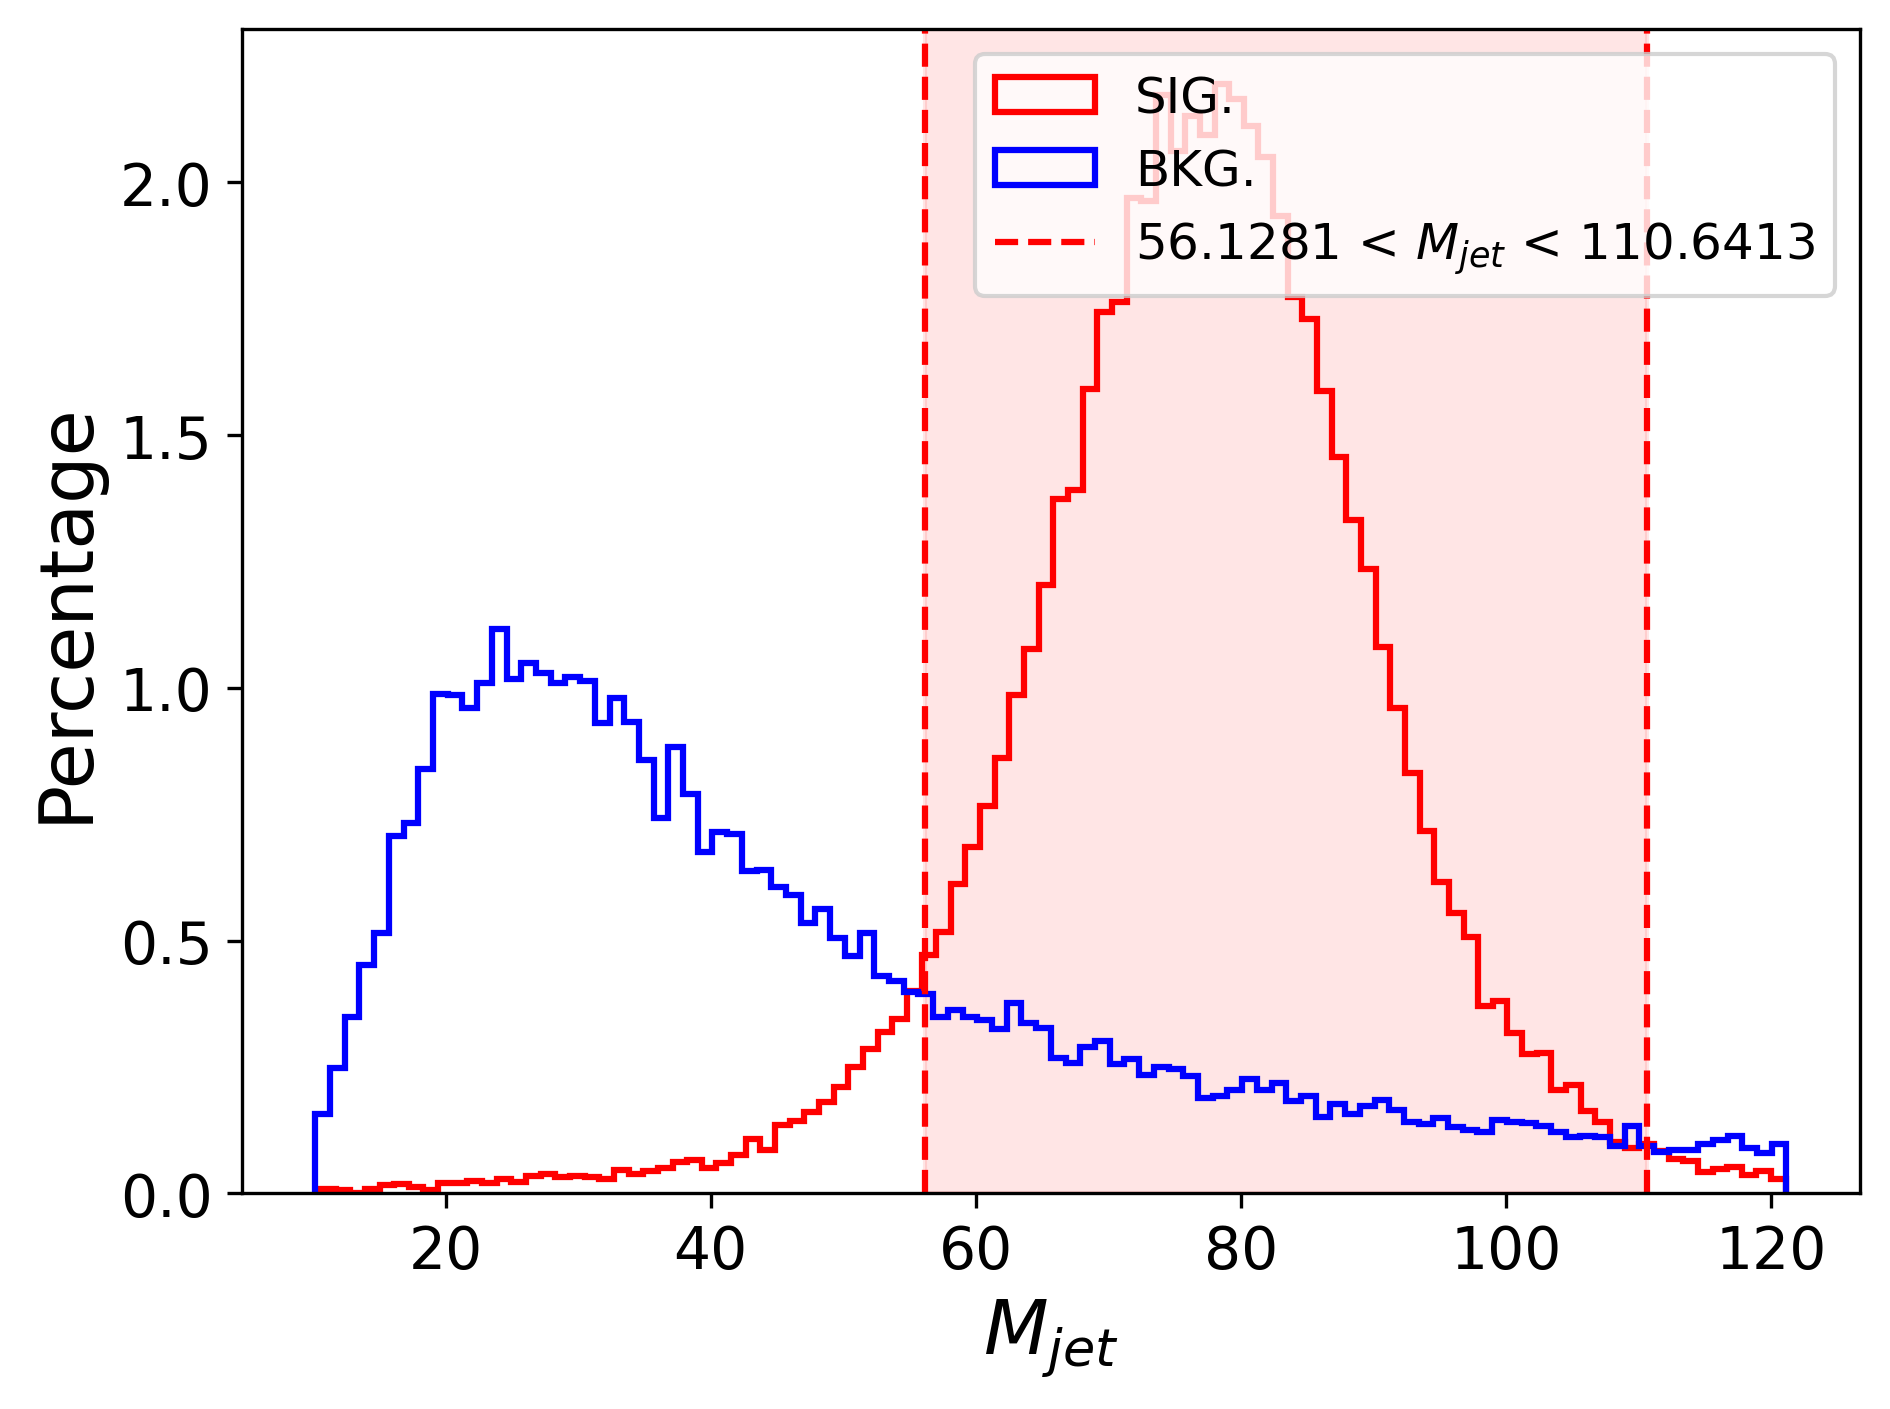

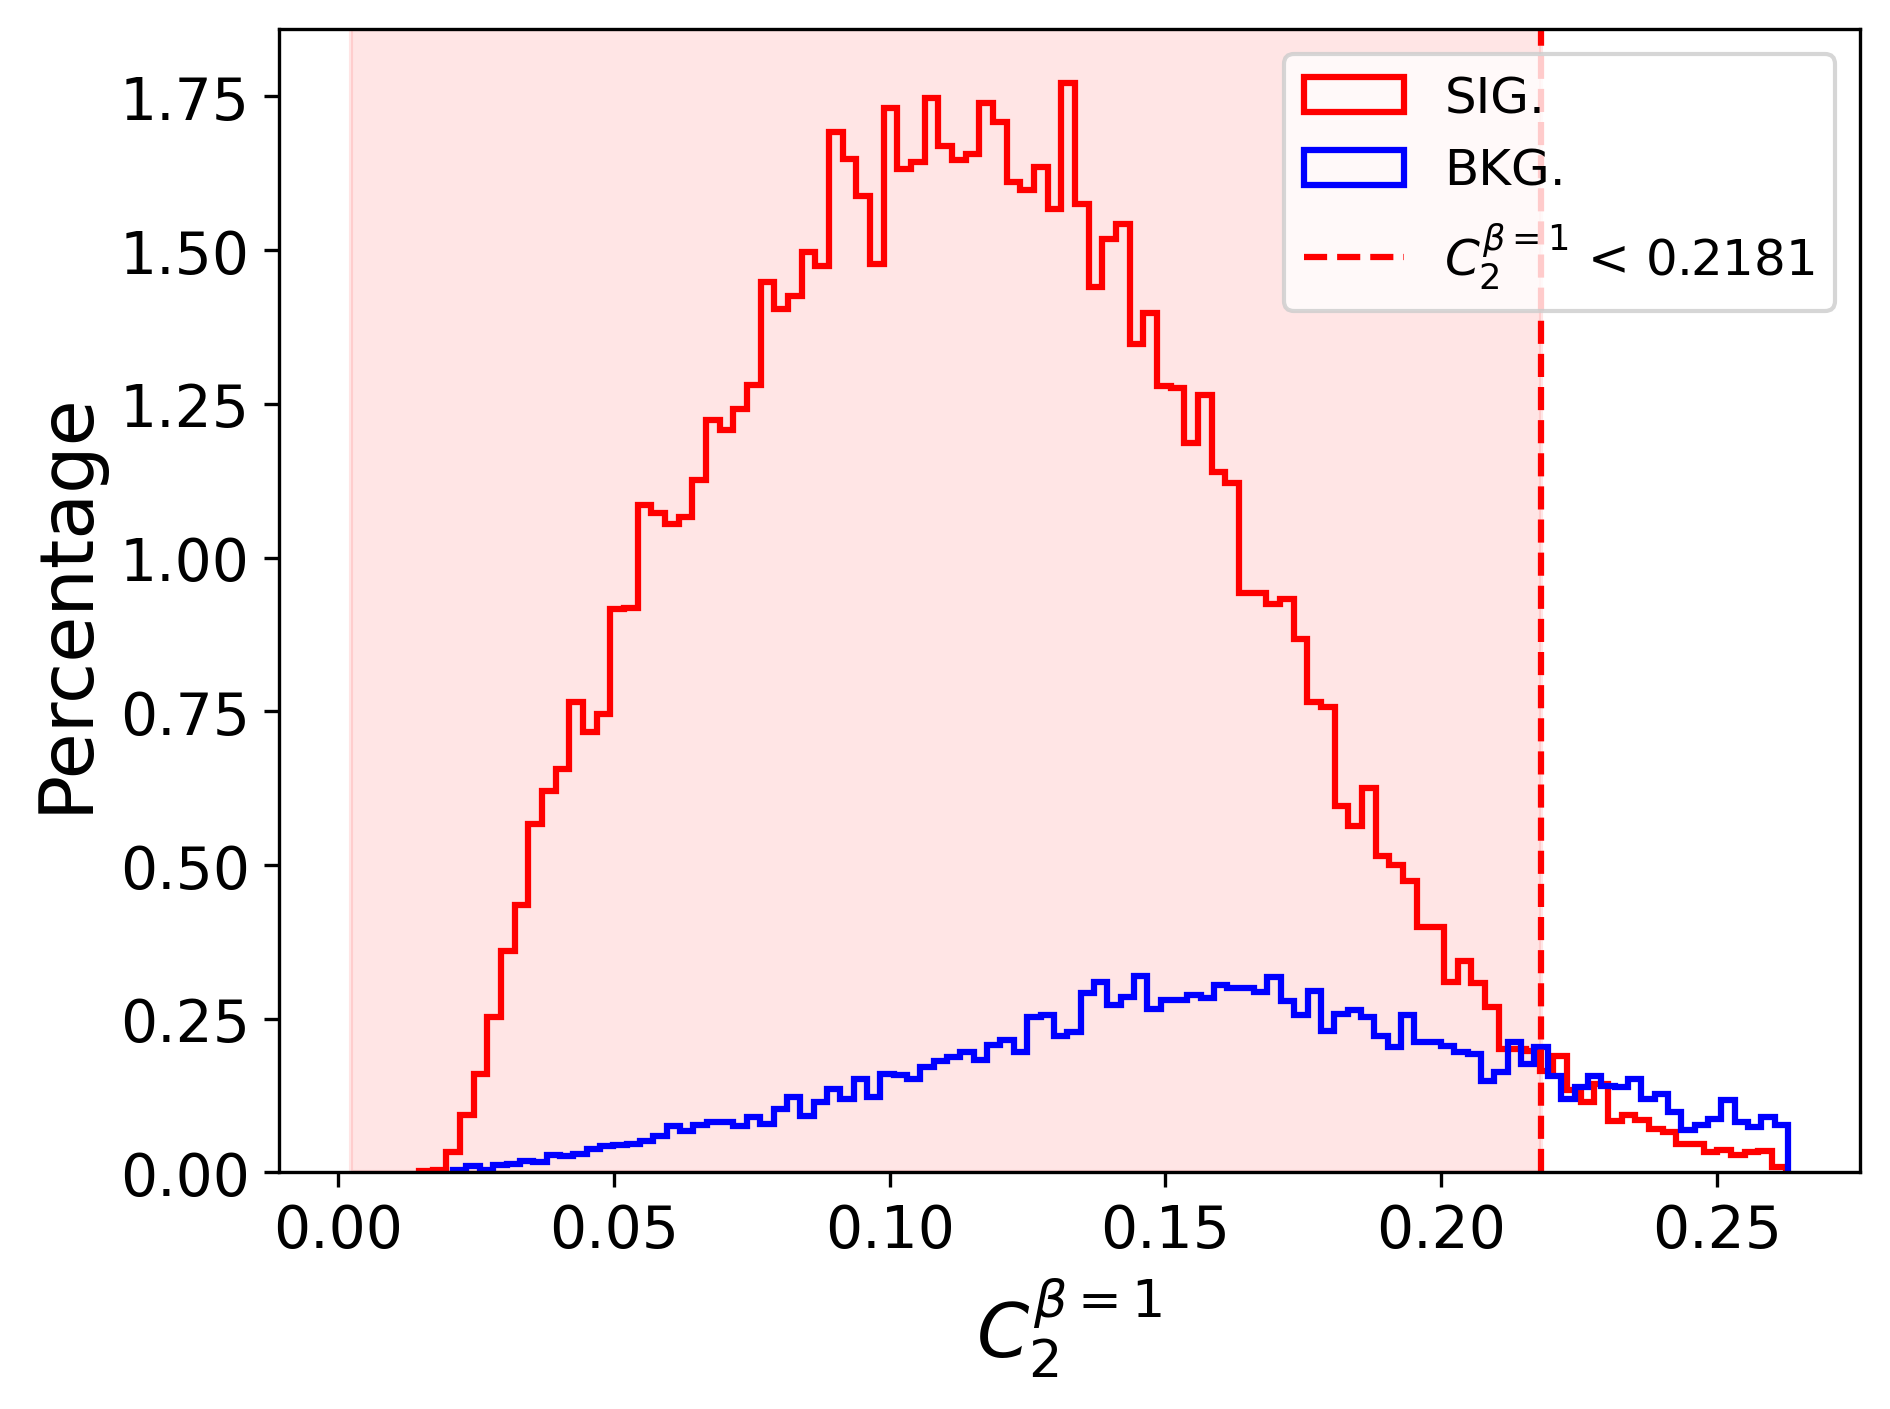

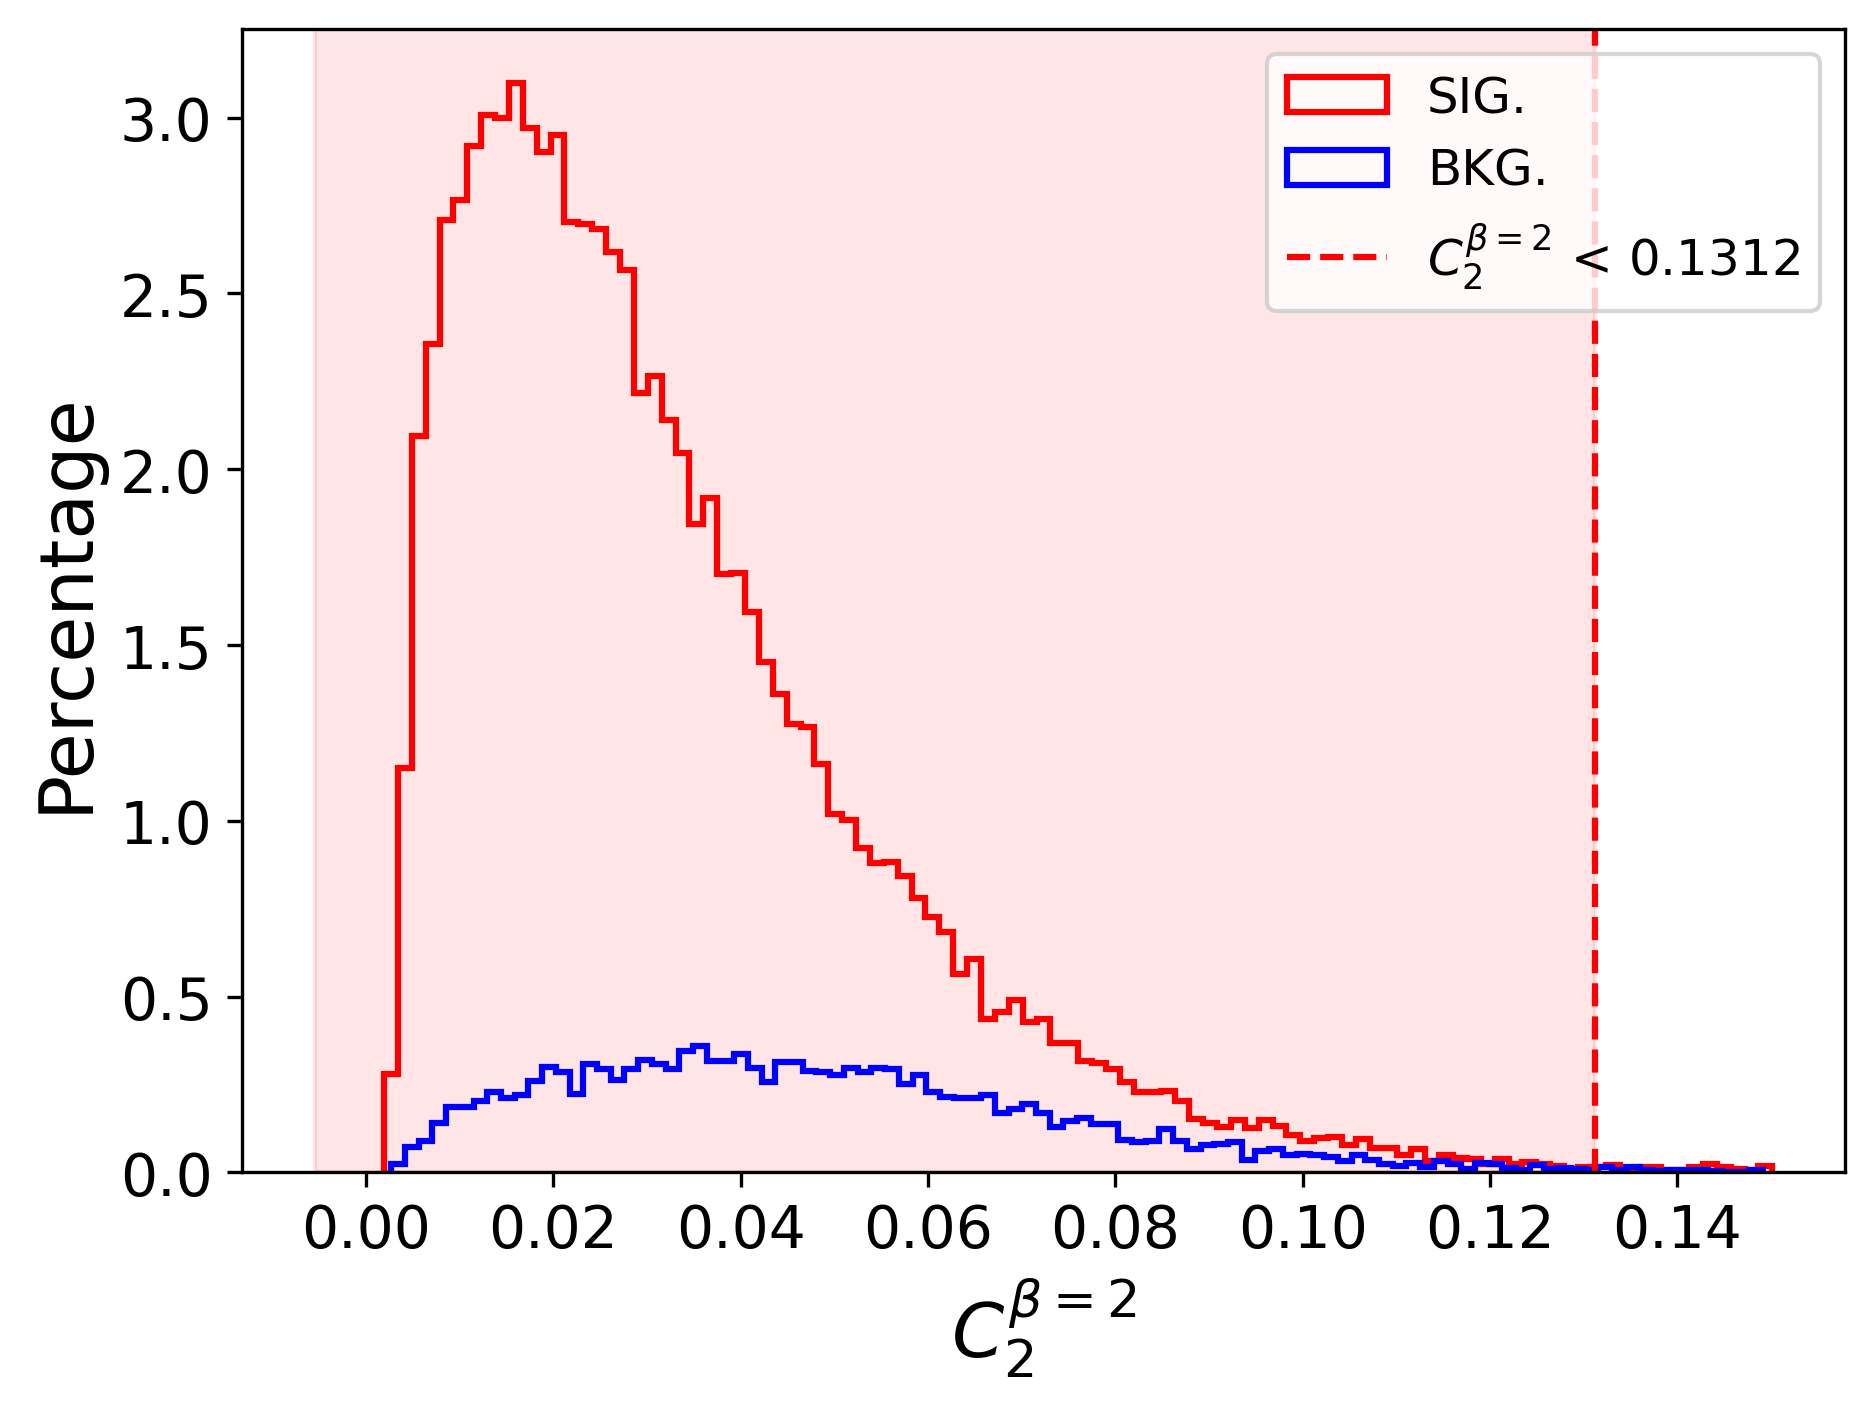

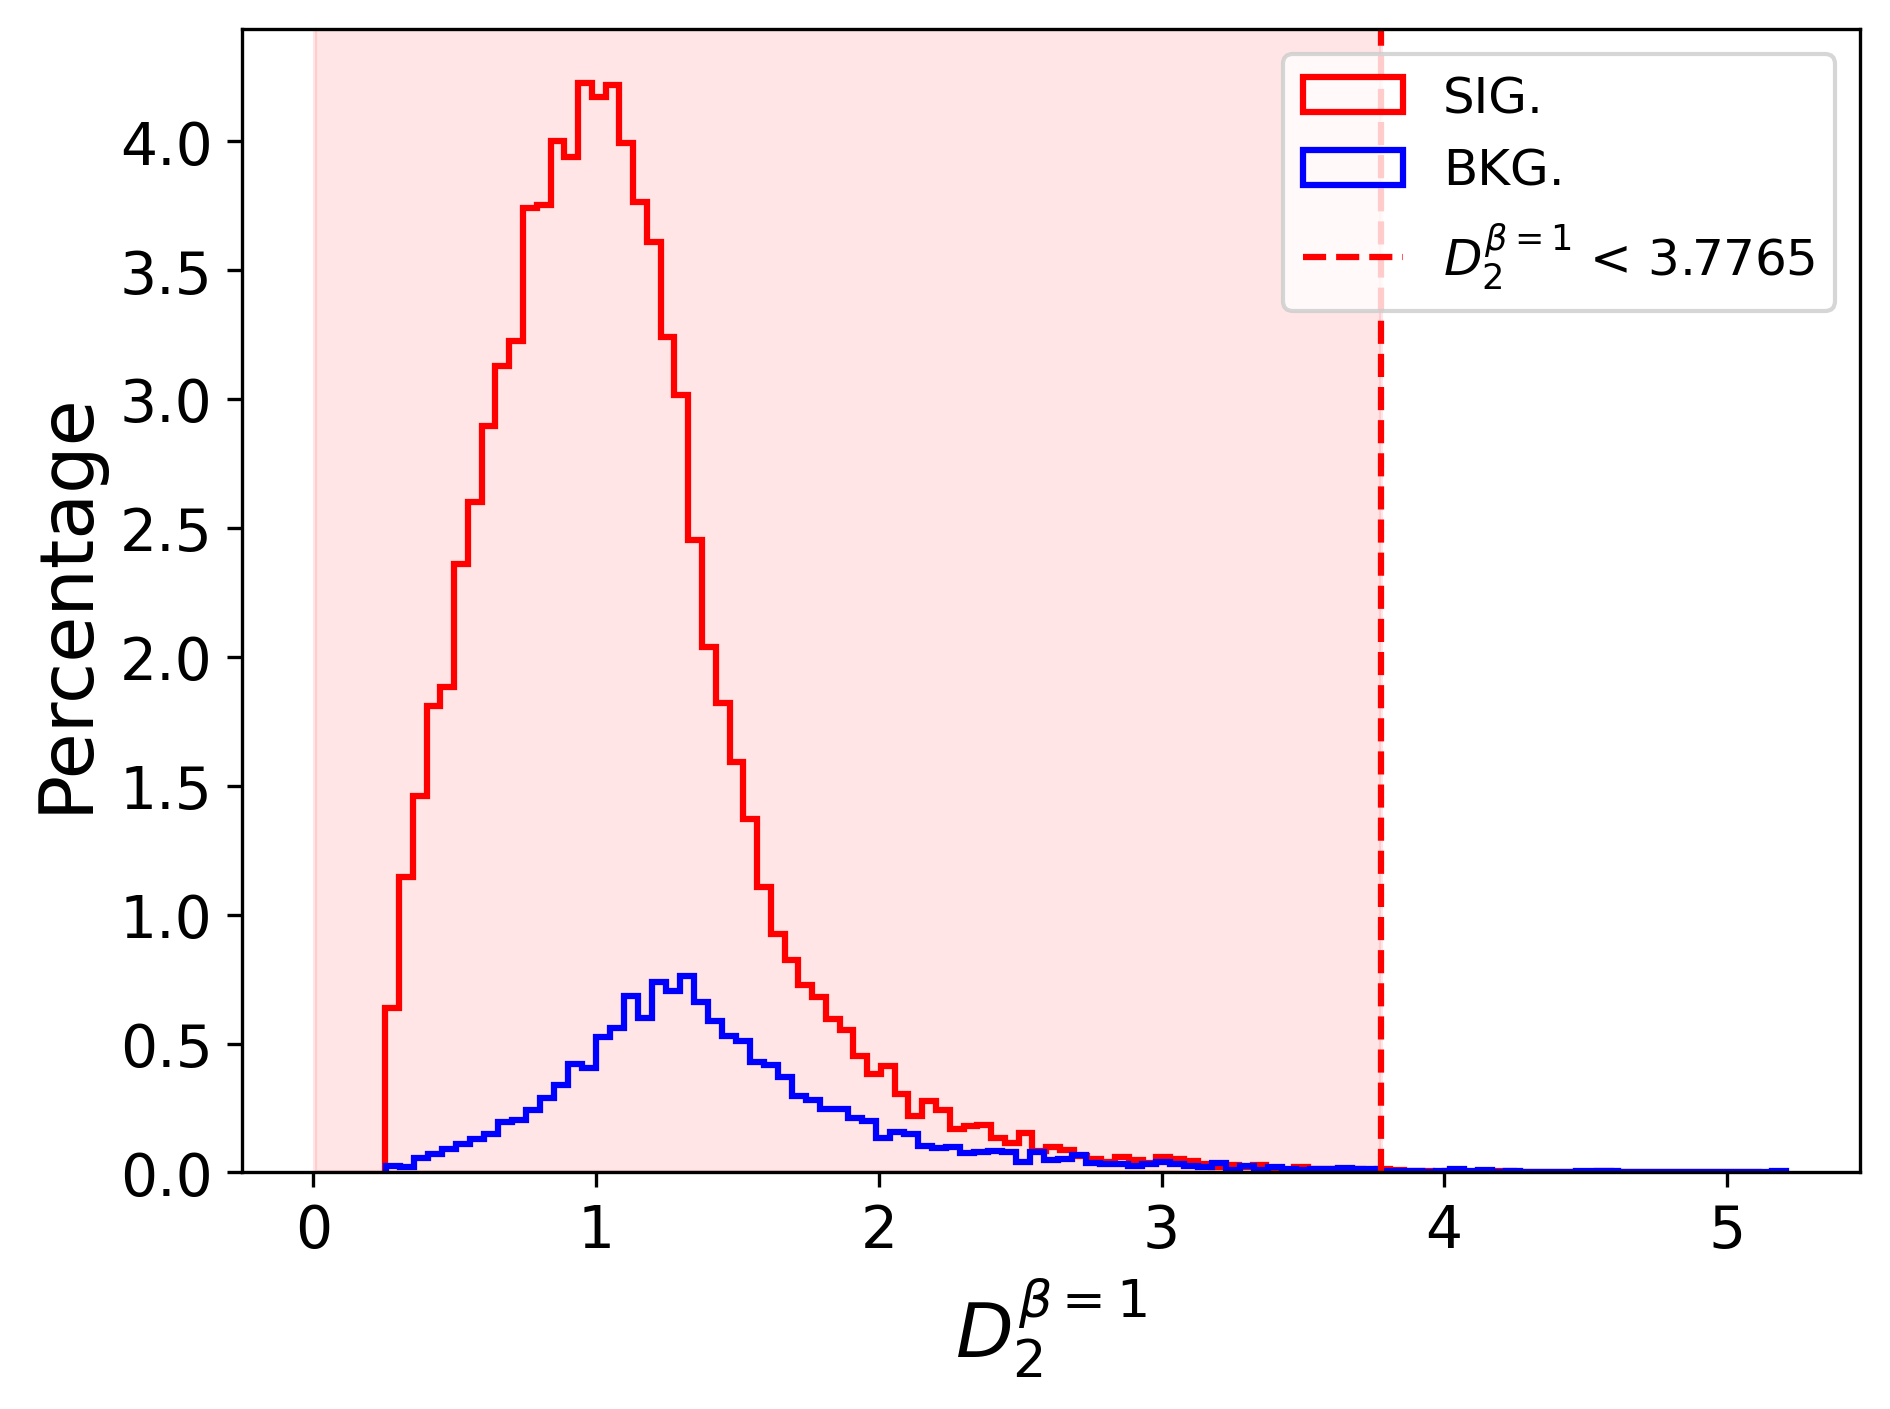

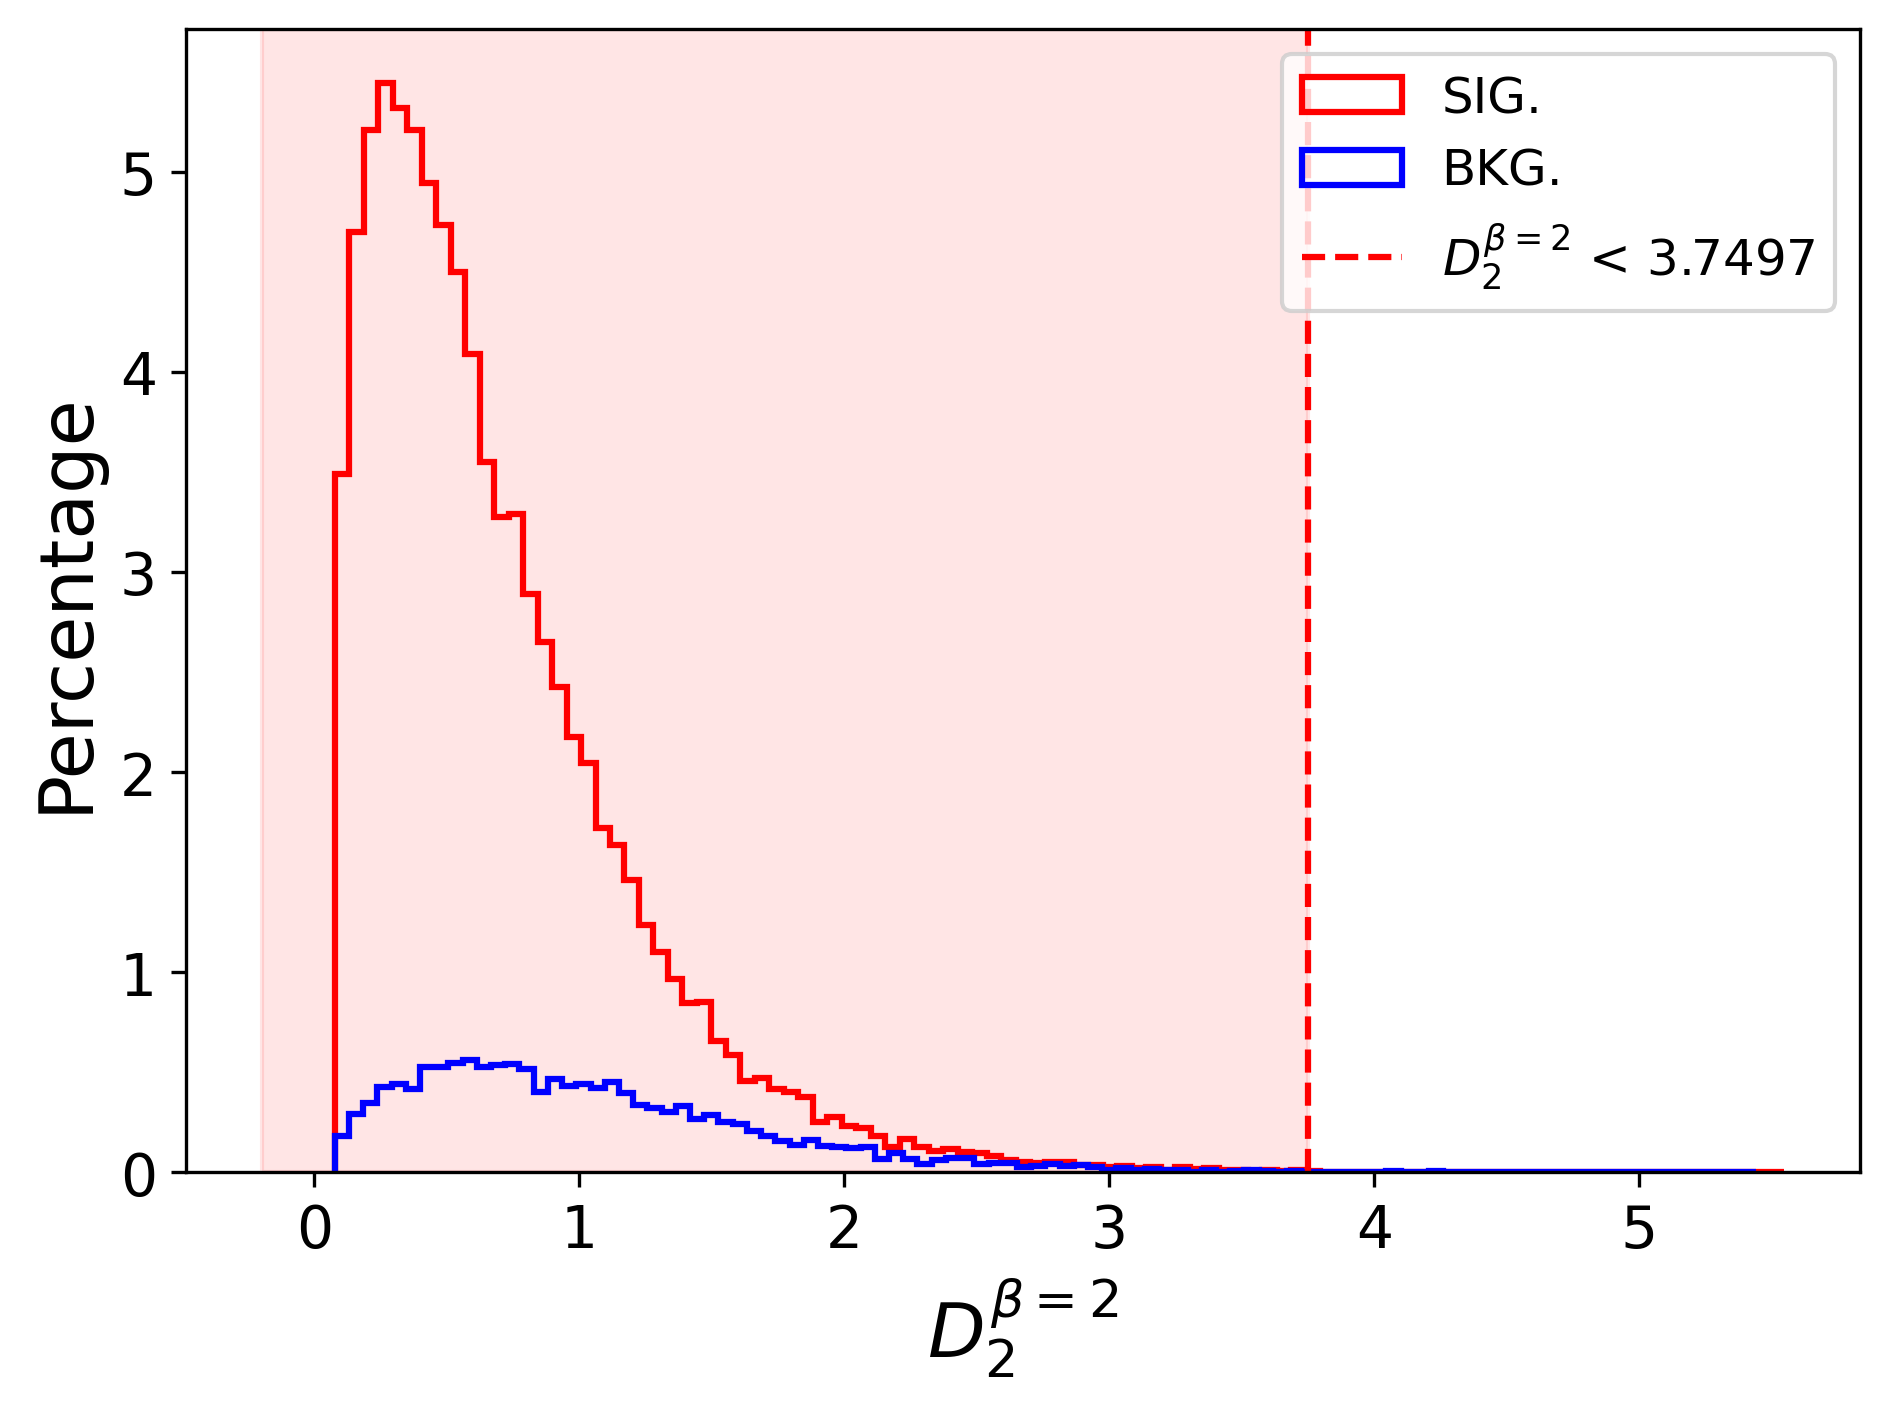

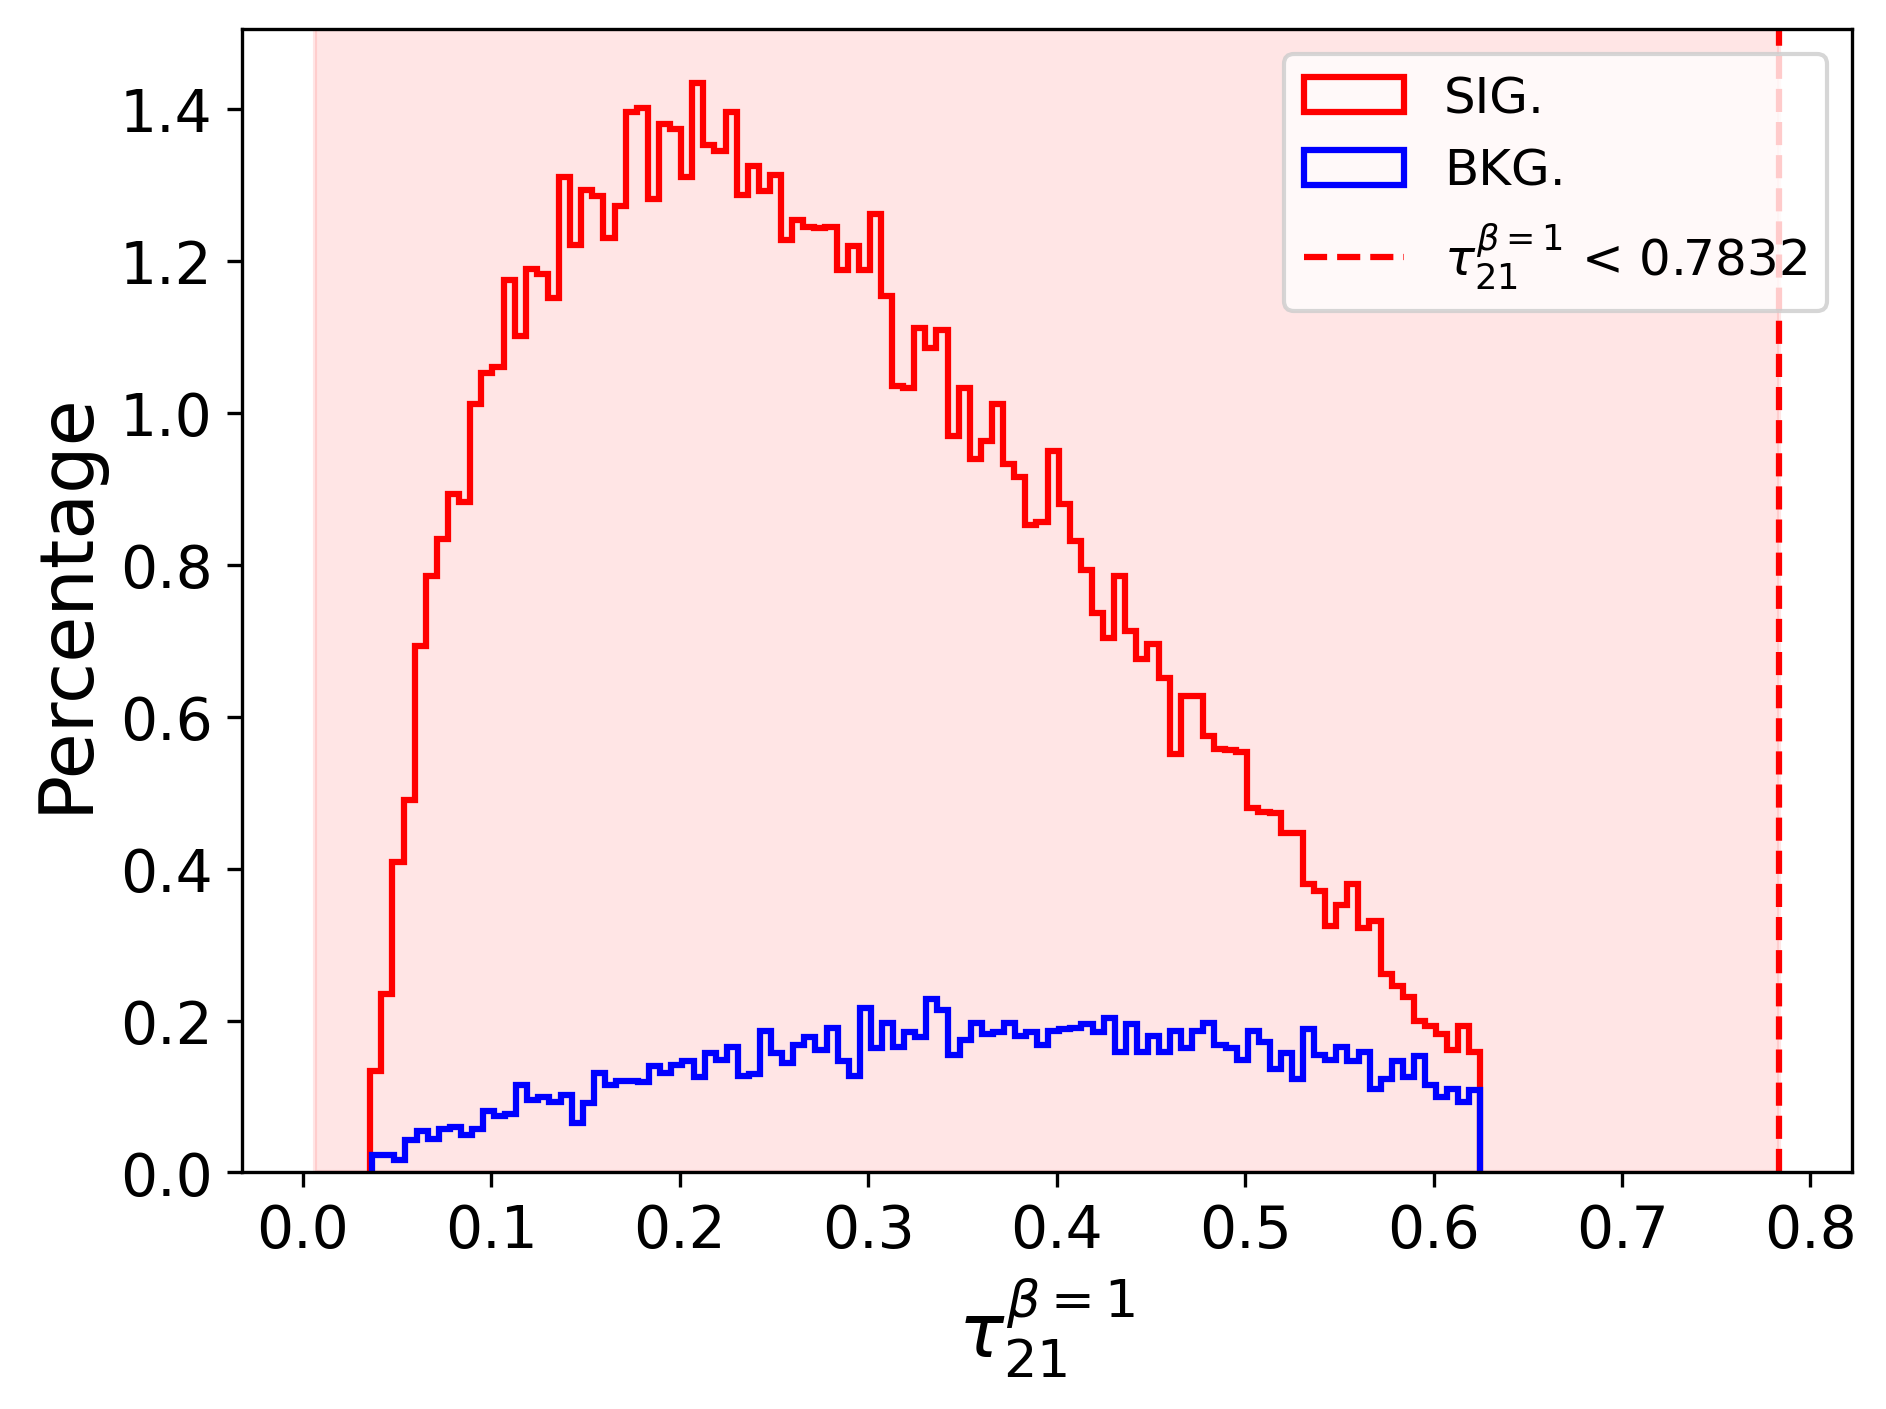

In [9]:
# Figure: learned cuts
features_str = [tex_to_str(feature) for feature in features]

df = pd.DataFrame(x_test, columns=features_str)
df["y"] = y_test.squeeze()

for i, feature in enumerate(features):
    sig = df.query("y == 1")[features_str[i]]
    bkg = df.query("y == 0")[features_str[i]]
    weights_sig = 100 * np.ones_like(sig) / len(df)
    weights_bkg = 100 * np.ones_like(bkg) / len(df)

    plot_learned_cut(
        case=cut_cases[i],
        index=cut_indices[i],
        boundaries=cut_boundaries[i],
        expression=cut_expressions[i],
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
    )
    plot_learned_cut(
        case=cut_cases[i],
        index=cut_indices[i],
        boundaries=cut_boundaries[i],
        expression=cut_expressions[i],
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"learned_cut-{tex_to_str(feature)}(x10).pdf",
    )

    if isinstance(checkpoint, LearnableCutFlowSequentialModel):
        cut_query = checkpoint.cuts[i].expression.replace(
            features[i], f"`{features_str[i]}`"
        )
        df = df.query(cut_query)

In [10]:
# Analysis: learned importance (x10)
importance_score_means = []
importance_score_stds = []

for i in range(x_test.shape[1]):
    for checkpoint in checkpoints:
        assert checkpoint.cuts[i].case == checkpoints[0].cuts[i].case
        assert checkpoint.cuts[i].index == checkpoints[0].cuts[i].index

importance_scores = []
for checkpoint in checkpoints:
    importance_scores.append(checkpoint.importance.scores)

importance_scores_mean = ops.mean(importance_scores, axis=0)
importance_scores_std = ops.std(importance_scores, axis=0)

for i in range(x_test.shape[1]):
    print(f"{importance_scores_mean[i]:.4f} ± {importance_scores_std[i]:.4f}")

0.3967 ± 0.0091
0.1494 ± 0.0064
0.0683 ± 0.0032
0.1575 ± 0.0068
0.1510 ± 0.0074
0.0770 ± 0.0039


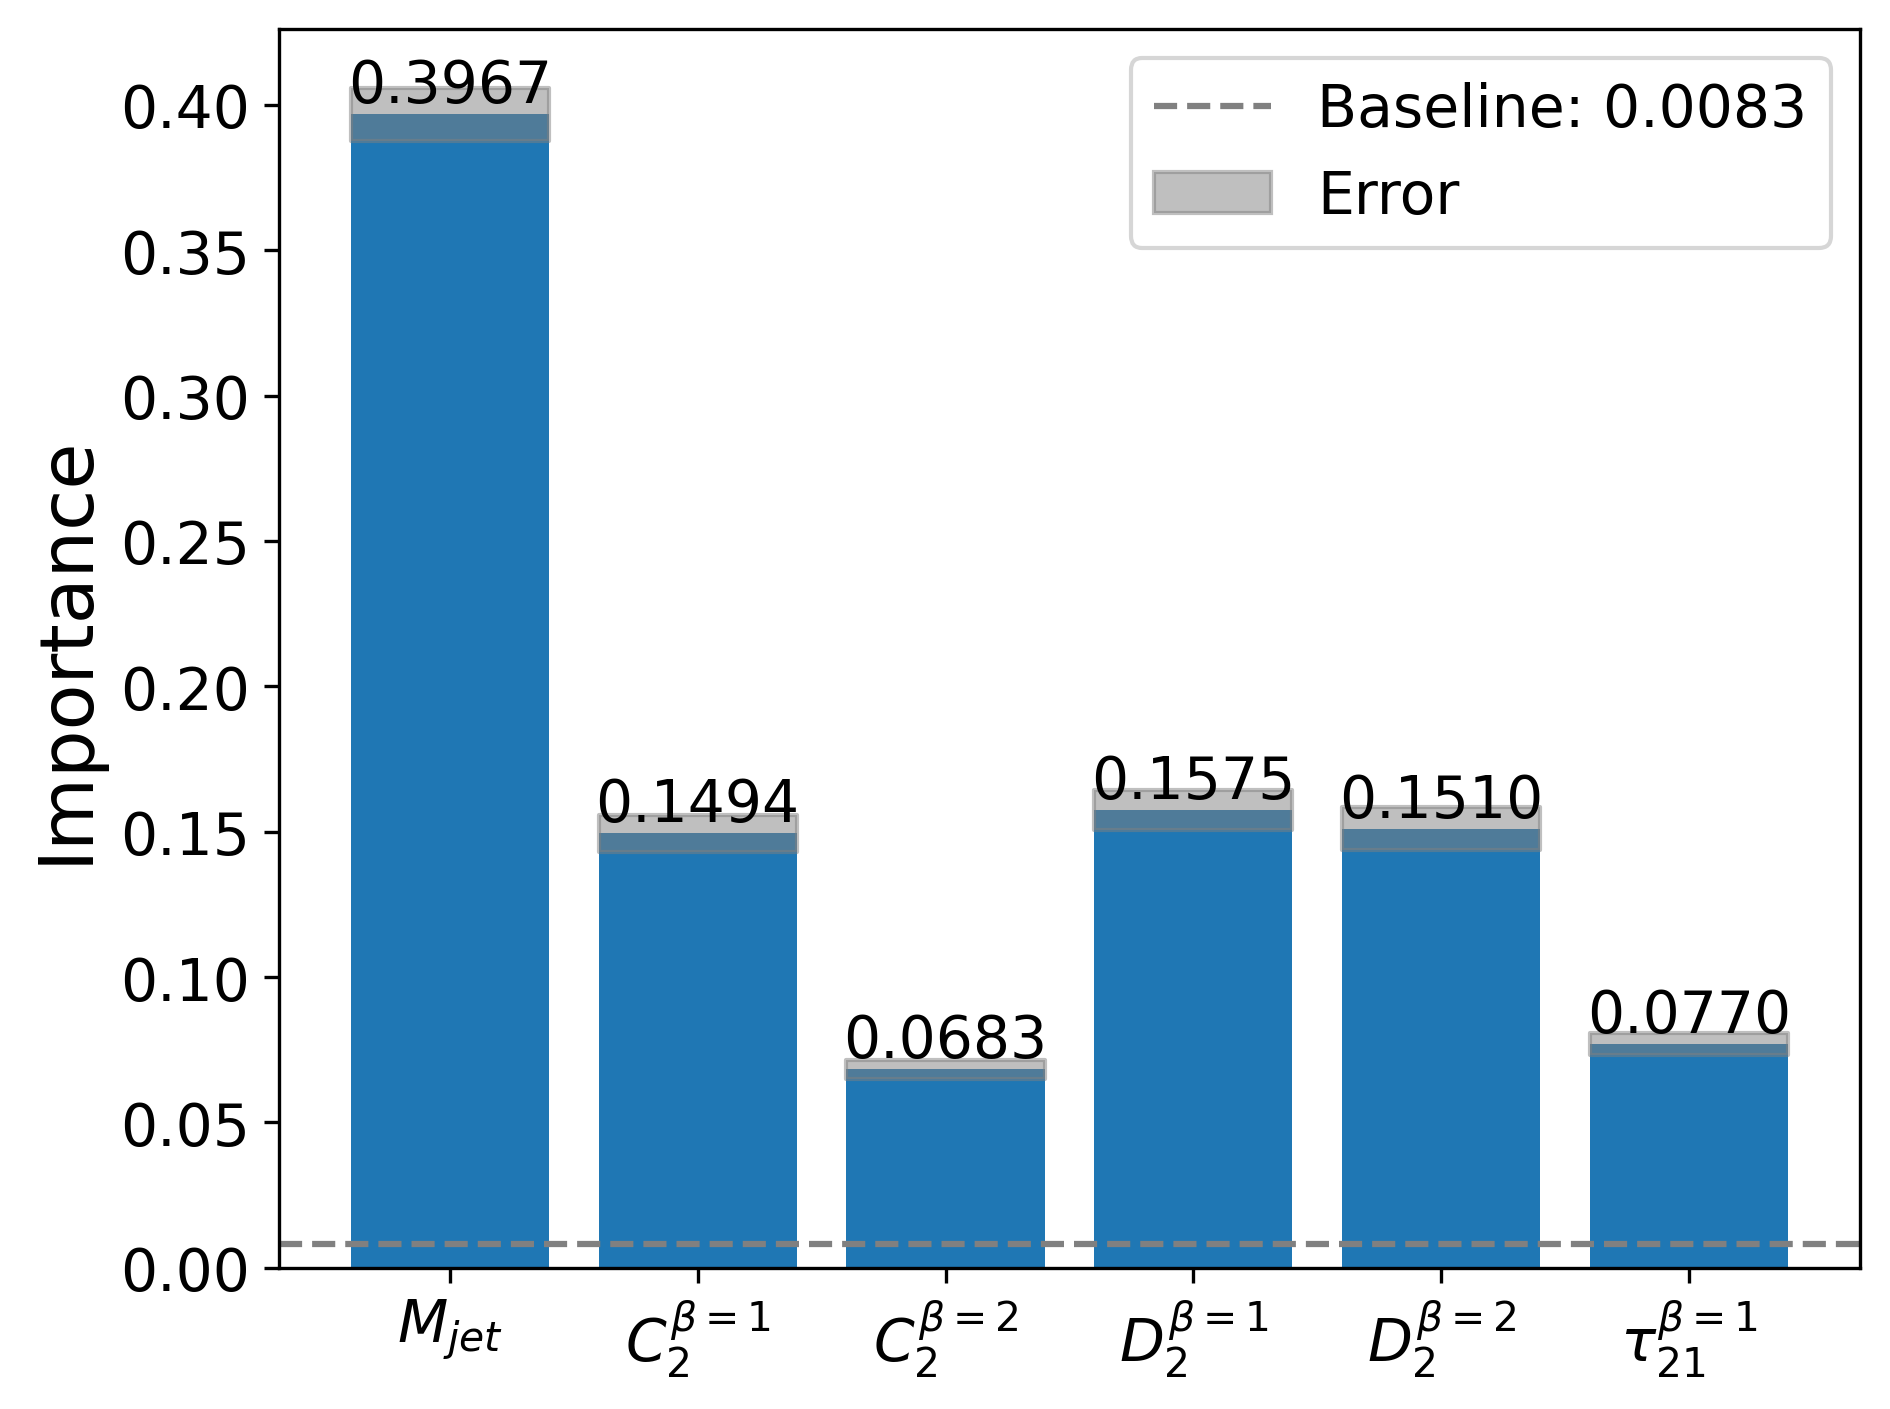

In [11]:
# Figure: learned importance (x10)
plot_learned_importance(
    scores=importance_scores_mean,
    errors=importance_scores_std,
    baseline=checkpoint.importance.baseline,
    features=features,
)
plot_learned_importance(
    scores=importance_scores_mean,
    errors=importance_scores_std,
    baseline=checkpoint.importance.baseline,
    features=features,
    to_file=FIGURES_DIR / "learned_importance(x10).pdf",
)